In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [14]:
# 1. load the raw clinical data from Python's built-in library
raw_data = load_breast_cancer()

In [17]:
# 2. Convert it into a clean table (Dataframe)with proper column names
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

In [18]:
# 3. Add the outcome column (0 = Malignant/Severe, 1 = Benign/Healthy)
df["outcome"] = raw_data.target

In [19]:
# 4. Keeping only 6 key features so the table isn't overwhelming
selected_columns = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean smoothness",
    "mean compactness",
    "mean symmetry",
    "outcome",
]
df =  df[selected_columns]

In [20]:
# 5. Looking at the first 5 rows of the new table
df.head()

,mean radius,mean texture,mean perimeter,mean smoothness,mean compactness,mean symmetry,outcome
0,17.99,10.38,122.80,0.11840,0.27760,0.2419,0
1,20.57,17.77,132.90,0.08474,0.07864,0.1812,0
2,19.69,21.25,130.00,0.10960,0.15990,0.2069,0
3,11.42,20.38,77.58,0.14250,0.28390,0.2597,0
4,20.29,14.34,135.10,0.10030,0.13280,0.1809,0


In [21]:
# 6. Check if there are any blank cells in our data
print("-- Missing Rows Check")
print(df.isnull().sum())

-- Missing Rows Check
mean radius         0
mean texture        0
mean perimeter      0
mean smoothness     0
mean compactness    0
mean symmetry       0
outcome             0
dtype: int64


In [22]:
# 7. Getting the basic stats: Averages, minimums and maximums
print("\n--- Summary Statistics---")
df.describe().T


--- Summary Statistics---


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040
outcome,569.0,0.627417,0.483918,0.00000,0.00000,1.00000,1.0000,1.0000


In [23]:
# 8. group the patients by their outcome and calculate the average for each group
df.groupby("outcome").mean()

,mean radius,mean texture,mean perimeter,mean smoothness,mean compactness,mean symmetry
outcome,,,,,,
0,17.462830,21.604906,115.365377,0.102898,0.145188,0.192909
1,12.146524,17.914762,78.075406,0.092478,0.080085,0.174186


In [24]:
# 9. Calculate how much the variables move together (Correlation)
correlation_matrix = df.corr()

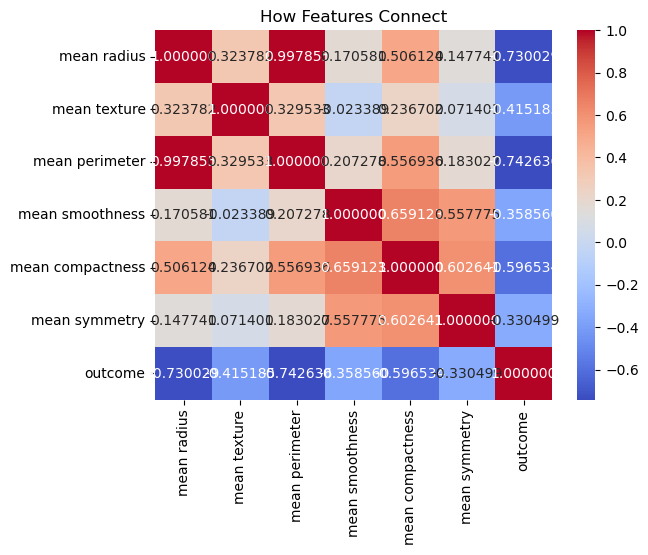

In [25]:
# 10. Draw the heatmap chart
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt="2f")
plt.title("How Features Connect")
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
# 11. Separate our data into the questions (X) and the final answer (y)
X = df.drop(columns=["outcome"])
y = df["outcome"]

In [56]:
# 12. Hide 20% of the data into a "test set" to quiz the model later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [57]:
# 13. Scale the data so large size numbers don't overwhelm small decimal numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {len(X_train_scaled)}, Testing rows: {len(X_test_scaled)}")

Training rows: 455, Testing rows: 114


In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
# 13. Initialize the math engine
model = LogisticRegression(random_state=42)

In [60]:
# 14. Let the engine study the training data to find patterns
model.fit(X_train_scaled, y_train)

print("The model has finished studying the clinical data!")

The model has finished studying the clinical data!


In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [62]:
# 15. Ask the model to guess the outcomes for the hidden test cases

guesses = model.predict(X_test_scaled)

In [63]:
# 16. Calculate the overall percentage of correct guesses
accuracy = accuracy_score(y_test, guesses)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

Overall Accuracy: 87.72%


In [64]:
# 17. Creating a diagnostic error scorecard

cm = confusion_matrix(y_test, guesses)
cm_table = pd.DataFrame(
    cm,
    index=["Actual Malignant", "Actual Benign"],
    columns=["Predicted Malignant", "Predicted Benign"],
)
cm_table

,Predicted Malignant,Predicted Benign
Actual Malignant,38,4
Actual Benign,10,62
